In [882]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime
import re
import glob
import datetime as dt

# Configuration
RESULTS_DIR = Path("../results")


In [883]:
%matplotlib widget

In [884]:
filename = "results/2026/01/23/full_swing_20260123-214855.json"  # Change this to your filename
if filename == "":
    year = str(dt.datetime.now().year)
    month = f"{dt.datetime.now().month:02d}"
    day = f"{dt.datetime.now().day:02d}"
    test = RESULTS_DIR / year / month / day
    if not Path(test).exists():
        print(f"No data found for {year}-{month}-{day}")
    filename = sorted(glob.glob(f"{str(test)}/full_swing*.json"))[-1][2:] # Change this to your filename
    filename = ("..") + (filename)

# Construct full path
if Path(filename).is_absolute():
    filepath = Path(filename)
else:
    # Extract date from filename (format: prefix_YYYYMMDD-HHMMSS.json)
    # Extract just the filename without directory if provided
    filename_only = Path(filename).name
    
    # Try to extract date from filename pattern: *_YYYYMMDD-*.json
    match = re.search(r'_(\d{8})-', filename_only)
    if match:
        date_str = match.group(1)  # YYYYMMDD
        year = date_str[:4]
        month = date_str[4:6]
        day = date_str[6:8]
        # Construct hierarchical path: results/YYYY/MM/DD/filename
        filepath = RESULTS_DIR / year / month / day / filename_only
    else:
        # Fallback: if date pattern not found, try direct path
        filepath = RESULTS_DIR / filename_only
        print(f"Warning: Could not extract date from filename. Using direct path.")

print(f"Loading data from: {filepath}")

Loading data from: ../results/2026/01/23/full_swing_20260123-214855.json


In [885]:
# # Enter the filename to load (without path, or with full path)
# filename = "results/2026/01/10/full_swing_20260110-121342.json"  # Change this to your filename

# # Construct full path
# if Path(filename).is_absolute():
#     filepath = Path(filename)
# else:
#     # Extract date from filename (format: prefix_YYYYMMDD-HHMMSS.json)
#     # Extract just the filename without directory if provided
#     filename_only = Path(filename).name
    
#     # Try to extract date from filename pattern: *_YYYYMMDD-*.json
#     match = re.search(r'_(\d{8})-', filename_only)
#     if match:
#         date_str = match.group(1)  # YYYYMMDD
#         year = date_str[:4]
#         month = date_str[4:6]
#         day = date_str[6:8]
#         # Construct hierarchical path: results/YYYY/MM/DD/filename
#         filepath = RESULTS_DIR / year / month / day / filename_only
#     else:
#         # Fallback: if date pattern not found, try direct path
#         filepath = RESULTS_DIR / filename_only
#         print(f"Warning: Could not extract date from filename. Using direct path.")

# print(f"Loading data from: {filepath}")


In [886]:
# with open(filepath, 'r') as f:
#     data = json.load(f)
# filepath.exists()
Path(filename).exists()

False

In [887]:
# Load the JSON data
with open(filepath, 'r') as f:
    data = json.load(f)

# Display metadata
print(f"Measurement timestamp: {data['timestamp']}")
print(f"Measurement time: {data['measurement_time']}")
if 'sec_utc' in data:
    dt = datetime.datetime.fromtimestamp(data['sec_utc'])
    print(f"UTC time: {dt.strftime('%Y-%m-%d %H:%M:%S UTC')}")
print(f"Sample rate: {data['sample_rate_hz']} Hz")
print(f"Duration: {data['measurement_duration_s']} s")
print(f"Buffer size: {data['buffer_size']} samples")
print(f"Channel range: ±{data['channel_range_v']} V")
print(f"Number of voltage samples: {len(data['voltage_data_v'])}")
print(f"Number of time samples: {len(data['time_s'])}")


Measurement timestamp: 20260123-214855
Measurement time: 2026-01-23 21:48:55
UTC time: 2026-01-23 21:48:55 UTC
Sample rate: 25000000.0 Hz
Duration: 0.0001 s
Buffer size: 2501 samples
Channel range: ±5.0 V
Number of voltage samples: 2501
Number of time samples: 2501


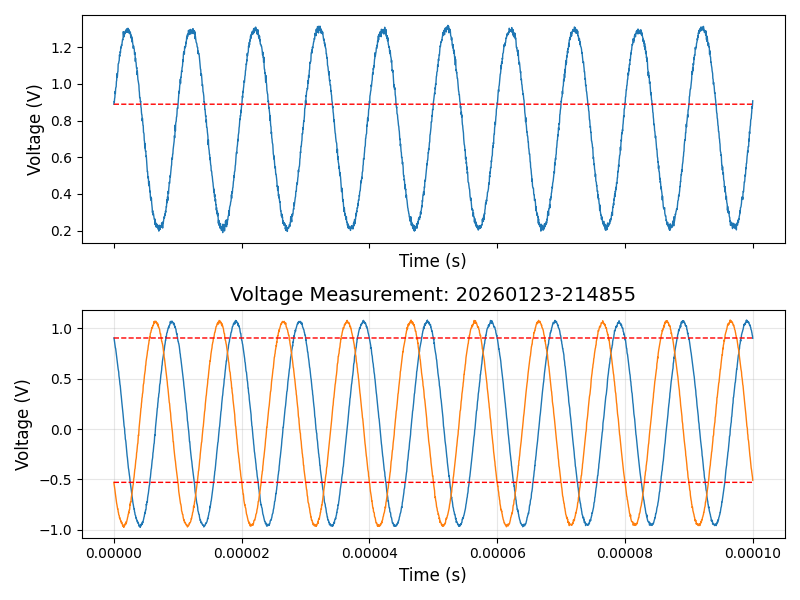


Voltage Statistics:
  Min: -0.974702 V
  Max: 1.079458 V
  Mean: 0.053453 V
  Std: 0.714059 V
133.68704621131053 1.079458366368108 -0.9747023281965497


In [888]:
# Extract data arrays
sampling_rate = data['sample_rate_hz']
modulation_frequency = data['modulation_frequency_hz']
time_for_quarter_period = 1/modulation_frequency/4
data_points_for_quarter_period = int(time_for_quarter_period*sampling_rate)+1

time_s = np.array(data['time_s'])  # Time in seconds
voltage_v = np.array(data['voltage_data_v'])  # Voltage in Volts
cosine_reference_v = np.array(data['cosine_reference_v'])
sine_reference_v = np.array(data['cosine_reference_v'][data_points_for_quarter_period+1:] + data['cosine_reference_v'][:data_points_for_quarter_period+1])

# Plot voltage vs time
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(time_s, voltage_v,linewidth=1)
axs[0].plot(time_s, np.min(voltage_v[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
axs[1].plot(time_s, cosine_reference_v,linewidth=1)
axs[1].plot(time_s, sine_reference_v,linewidth=1)
axs[1].plot(time_s, np.min(cosine_reference_v[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
axs[1].plot(time_s, np.min(sine_reference_v[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
axs[0].set_xlabel('Time (s)', fontsize=12)
axs[0].set_ylabel('Voltage (V)', fontsize=12)
axs[1].set_xlabel('Time (s)', fontsize=12)
axs[1].set_ylabel('Voltage (V)', fontsize=12)
plt.title(f'Voltage Measurement: {data["timestamp"]}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nVoltage Statistics:")
print(f"  Min: {np.min(cosine_reference_v):.6f} V")
print(f"  Max: {np.max(cosine_reference_v):.6f} V")
print(f"  Mean: {np.mean(cosine_reference_v):.6f} V")
print(f"  Std: {np.std(cosine_reference_v):.6f} V")

print(sum(sine_reference_v), max(sine_reference_v), min(sine_reference_v))


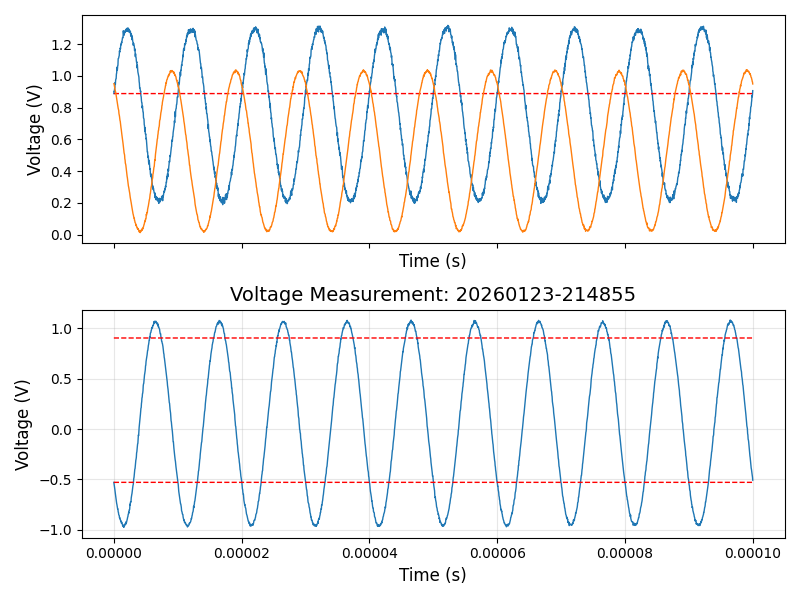


Voltage Statistics:
  Min: -0.974702 V
  Max: 1.079458 V
  Mean: 0.053453 V
  Std: 0.714059 V
133.68704621131053 1.079458366368108 -0.9747023281965497


In [889]:
# Extract data arrays
sampling_rate = data['sample_rate_hz']
modulation_frequency = data['modulation_frequency_hz']
time_for_quarter_period = 1/modulation_frequency/4
data_points_for_quarter_period = int(time_for_quarter_period*sampling_rate)+1

time_s = np.array(data['time_s'])  # Time in seconds
voltage_v = np.array(data['voltage_data_v'])  # Voltage in Volts
cosine_reference_v = np.array(data['cosine_reference_v'])
sine_reference_v = np.array(data['cosine_reference_v'][data_points_for_quarter_period+1:] + data['cosine_reference_v'][:data_points_for_quarter_period+1])

# Plot voltage vs time
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(time_s, voltage_v,linewidth=1)
axs[0].plot(time_s, np.min(voltage_v[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
axs[0].plot(time_s, cosine_reference_v/2+0.5,linewidth=1)
axs[1].plot(time_s, sine_reference_v,linewidth=1)
axs[1].plot(time_s, np.min(cosine_reference_v[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
axs[1].plot(time_s, np.min(sine_reference_v[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
axs[0].set_xlabel('Time (s)', fontsize=12)
axs[0].set_ylabel('Voltage (V)', fontsize=12)
axs[1].set_xlabel('Time (s)', fontsize=12)
axs[1].set_ylabel('Voltage (V)', fontsize=12)
plt.title(f'Voltage Measurement: {data["timestamp"]}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nVoltage Statistics:")
print(f"  Min: {np.min(cosine_reference_v):.6f} V")
print(f"  Max: {np.max(cosine_reference_v):.6f} V")
print(f"  Mean: {np.mean(cosine_reference_v):.6f} V")
print(f"  Std: {np.std(cosine_reference_v):.6f} V")

print(sum(sine_reference_v), max(sine_reference_v), min(sine_reference_v))

